In [ ]:

# --------------------------------------------------
# 1. Import Libraries
# --------------------------------------------------

import tensorflow as tf
from tensorflow.keras import layers, models
import zipfile
import os


# --------------------------------------------------
# 2. Download the Cats vs Dogs ZIP file
# --------------------------------------------------

!pip install -q gdown

import gdown

file_id = "14zAvLt1t-CMB0iXtNPZjh90Y6FHzKbn1"

url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(
    url,
    "cats_and_dogs_filtered.zip",
    quiet=False
)


# --------------------------------------------------
# 3. Extract the ZIP file
# --------------------------------------------------

with zipfile.ZipFile("cats_and_dogs_filtered.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully!")


# --------------------------------------------------
# 4. Set Dataset Paths
# --------------------------------------------------

base_dir = "/content/cats_and_dogs_filtered"

train_dir = os.path.join(base_dir, "train")
validation_dir = os.path.join(base_dir, "validation")

print("Train:", train_dir)
print("Validation:", validation_dir)


# --------------------------------------------------
# 5. Load Training and Validation Images
# --------------------------------------------------

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(128, 128),
    batch_size=32,
    shuffle=True
)

val_data = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(128, 128),
    batch_size=32,
    shuffle=False
)

print("Classes:", train_data.class_names)


# --------------------------------------------------
# 6. Build CNN Model
# --------------------------------------------------

model = models.Sequential([

    # Normalize pixel values
    layers.Rescaling(1./255,
                     input_shape=(128, 128, 3)),

    # First Convolution Layer
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Second Convolution Layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolution Layer
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation='relu'),

    # Binary Classification Output
    layers.Dense(1, activation='sigmoid')
])


# --------------------------------------------------
# 7. Display CNN Model
# --------------------------------------------------

model.summary()


# --------------------------------------------------
# 8. Compile the Model
# --------------------------------------------------

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# --------------------------------------------------
# 9. Train the CNN
# --------------------------------------------------

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)


# --------------------------------------------------
# 10. Evaluate the Model
# --------------------------------------------------

loss, accuracy = model.evaluate(val_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)



Downloading...
From (original): https://drive.google.com/uc?id=14zAvLt1t-CMB0iXtNPZjh90Y6FHzKbn1
From (redirected): https://drive.google.com/uc?id=14zAvLt1t-CMB0iXtNPZjh90Y6FHzKbn1&confirm=t&uuid=cf86d6ae-ef38-41ef-83f5-c8d4d6f0b900
To: /content/cats_and_dogs_filtered.zip
100%|██████████| 137M/137M [00:00<00:00, 143MB/s]


Dataset extracted successfully!
Train: /content/cats_and_dogs_filtered/train
Validation: /content/cats_and_dogs_filtered/validation
Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Classes: ['cats', 'dogs']


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.5295 - loss: 0.7096 - val_accuracy: 0.6460 - val_loss: 0.6682
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.6200 - loss: 0.6432 - val_accuracy: 0.6120 - val_loss: 0.6543
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.6870 - loss: 0.5896 - val_accuracy: 0.6700 - val_loss: 0.6048
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.7375 - loss: 0.5302 - val_accuracy: 0.7160 - val_loss: 0.5723
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.7645 - loss: 0.4838 - val_accuracy: 0.6940 - val_loss: 0.5953
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.7970 - loss: 0.4329 - val_accuracy: 0.7140 - val_loss: 0.6062
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.8180 - loss: 0.3820 - val_accuracy: 0.7000 - val_loss: 0.6575
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.8660 - loss: 0.3096 - val_accuracy: 0.7040 - val_loss:

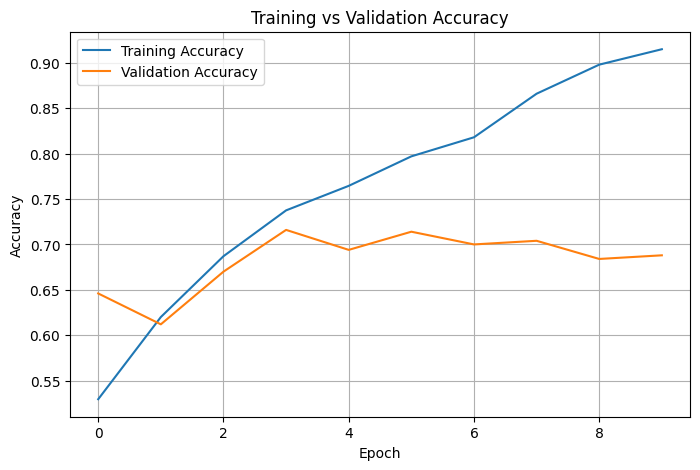

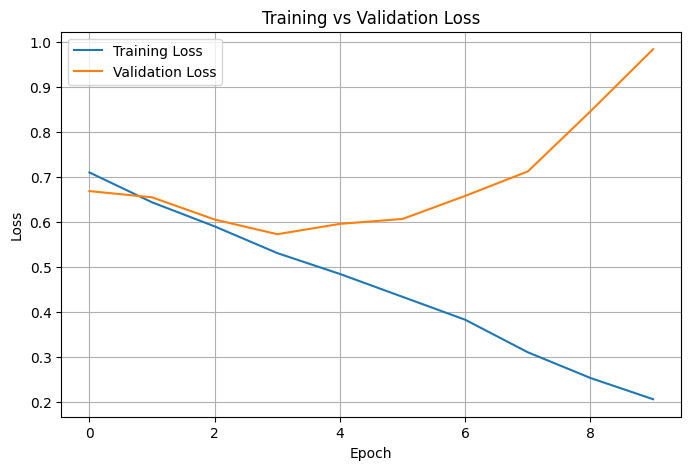

In [ ]:
import matplotlib.pyplot as plt

# --------------------------------------------------
# Plot Training and Validation Accuracy
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()


# --------------------------------------------------
# Plot Training and Validation Loss
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# PART B: MULTI-CLASS IMAGE CLASSIFICATION USING CNN
# Fashion-MNIST
# ============================================================

import os
import zipfile
import gzip
import struct
import urllib.request
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# ------------------------------------------------------------
# 1. Download Fashion-MNIST ZIP file
# ------------------------------------------------------------

zip_url = "https://github.com/zalandoresearch/fashion-mnist/archive/refs/heads/master.zip"
zip_path = "/content/fashion-mnist.zip"

urllib.request.urlretrieve(zip_url, zip_path)

print("ZIP file downloaded successfully!")


# ------------------------------------------------------------
# 2. Extract ZIP file
# ------------------------------------------------------------

extract_path = "/content/fashion_mnist"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP file extracted successfully!")


# ------------------------------------------------------------
# 3. Dataset path
# ------------------------------------------------------------

data_path = "/content/fashion_mnist/fashion-mnist-master/data/fashion"


# ------------------------------------------------------------
# 4. Extract .gz files
# ------------------------------------------------------------

gz_files = [
    "train-images-idx3-ubyte.gz",
    "train-labels-idx1-ubyte.gz",
    "t10k-images-idx3-ubyte.gz",
    "t10k-labels-idx1-ubyte.gz"
]

for file in gz_files:

    gz_path = os.path.join(data_path, file)
    output_path = os.path.join(data_path, file[:-3])

    if not os.path.exists(output_path):
        with gzip.open(gz_path, "rb") as f_in:
            with open(output_path, "wb") as f_out:
                f_out.write(f_in.read())

print("Dataset files extracted successfully!")


# ------------------------------------------------------------
# 5. Load Images
# ------------------------------------------------------------

def load_images(filename):

    with open(filename, "rb") as f:

        magic, num, rows, cols = struct.unpack(
            ">IIII",
            f.read(16)
        )

        data = np.frombuffer(
            f.read(),
            dtype=np.uint8
        )

        return data.reshape(num, rows, cols)


# ------------------------------------------------------------
# 6. Load Labels
# ------------------------------------------------------------

def load_labels(filename):

    with open(filename, "rb") as f:

        magic, num = struct.unpack(
            ">II",
            f.read(8)
        )

        return np.frombuffer(
            f.read(),
            dtype=np.uint8
        )


# ------------------------------------------------------------
# 7. Read Training and Testing Data
# ------------------------------------------------------------

x_train = load_images(
    os.path.join(data_path, "train-images-idx3-ubyte")
)

y_train = load_labels(
    os.path.join(data_path, "train-labels-idx1-ubyte")
)

x_test = load_images(
    os.path.join(data_path, "t10k-images-idx3-ubyte")
)

y_test = load_labels(
    os.path.join(data_path, "t10k-labels-idx1-ubyte")
)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)


# ------------------------------------------------------------
# 8. Normalize Images
# ------------------------------------------------------------

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


# ------------------------------------------------------------
# 9. Reshape Images
# ------------------------------------------------------------

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


# ------------------------------------------------------------
# 10. Build CNN Model
# ------------------------------------------------------------

model = models.Sequential([

    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    # 10 classes - Softmax
    layers.Dense(
        10,
        activation="softmax"
    )
])


# ------------------------------------------------------------
# 11. Display Model
# ------------------------------------------------------------

model.summary()


# ------------------------------------------------------------
# 12. Compile Model
# ------------------------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=0.01
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# 13. Train Model
# ------------------------------------------------------------

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)


# ------------------------------------------------------------
# 14. Evaluate Model
# ------------------------------------------------------------

loss, accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


ZIP file downloaded successfully!
ZIP file extracted successfully!
Dataset files extracted successfully!
Training data: (60000, 28, 28)
Testing data: (10000, 28, 28)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.6693 - loss: 0.9472 - val_accuracy: 0.7482 - val_loss: 0.6533
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.7953 - loss: 0.5507 - val_accuracy: 0.8163 - val_loss: 0.5047
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.8280 - loss: 0.4709 - val_accuracy: 0.8428 - val_loss: 0.4472
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.8450 - loss: 0.4293 - val_accuracy: 0.8462 - val_loss: 0.4318
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.8555 - loss: 0.3991 - val_accuracy: 0.8524 - val_loss: 0.4079
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 30ms/step - accuracy: 0.8623 - loss: 0.3780 - val_accuracy: 0.8669 - val_loss: 0.3685
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.8698 - loss: 0.3611 - val_accuracy: 0.8673 - val_loss: 0.3700
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.8756 -